In [9]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
from tqdm import tqdm
import joblib
from pathlib import Path

In [10]:
year = 2021
RAW_XY_FOLDERPATH = Path(f'../data/silver/Xy-{year}')

# Load data

In [11]:
raw_Xy = pd.read_parquet(RAW_XY_FOLDERPATH / "Xy.parquet")
metadata_df = pd.read_parquet(RAW_XY_FOLDERPATH / "metadata_df.parquet")

raw_Xy.head(1)

,red,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,red_11x11_median,...,ndwi_11x11_var,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median
1,0.121569,0.121569,0.109804,0.129412,0.007843,0.117647,0.109804,0.129412,0.007843,0.117647,...,-0.230769,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099


# Build Xy

In [12]:
def get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(X):
    features = ['blue', "green", "red", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
    features += ['scl', 'region']
    features += ['tci', 'ndvi', 'evi', 'evi2', 'ndre_b5', 'ndre_b6', 'ndre_b7', 'gndvi', 'ndwi']
    features += ['valid_observations']
    features += ['cloud_confidence']
    features += [e for e in X.columns if any(k in e for k in ['3x3', '5x5', '11x11'])]
    return X[features + ['y']]

Xy = get_base_and_scl_and_obs_cnt_and_cloud_conf_and_advanced_features(raw_Xy)
Xy.head(1)

,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median,y
1,0.058824,0.086275,0.121569,0.160784,0.180392,0.196078,0.196078,0.203922,0.239216,0.180392,...,0.036183,0.25,0.083682,-0.099099,0.106383,0.050505,0.019608,0.132626,-0.099099,False


# Prep hyperparam optimization

In [22]:
import numpy as np
import optuna
import lightgbm as lgb
from sklearn.model_selection import GroupKFold
from sklearn.metrics import f1_score, precision_score, recall_score

def optuna_objective_factory(X, y, groups, n_splits: int = 100):
    # Safely determine max possible splits based on unique groups
    unique_groups = len(np.unique(groups))
    actual_splits = min(n_splits, unique_groups)
    
    if actual_splits < n_splits:
        print(f"Warning: Requested {n_splits} splits, but only found {unique_groups} unique groups. Adjusting n_splits to {actual_splits}.")

    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 100),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 2, 15),
            'num_leaves': trial.suggest_int('num_leaves', 10, 256),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
            'n_jobs': -1,
            'verbose': -1,
            'random_state': 42
        }
        
        gkf = GroupKFold(n_splits=actual_splits)
        
        # Initialize lists to store metrics and raw arrays
        true_f1s, true_precisions, true_recalls = [], [], []
        false_f1s, false_precisions, false_recalls = [], [], []
        all_yhat_vals, all_y_vals = [], []
        
        for train_idx, val_idx in gkf.split(X, y, groups):
            # Safe slicing regardless of whether X/y are pandas DataFrames/Series or numpy arrays
            X_train = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
            y_train = y.iloc[train_idx]
            y_val = y.iloc[val_idx] 
            
            # Fit/predict
            model = lgb.LGBMClassifier(**param)
            model.fit(X_train, y_train)
            yhat_val = model.predict(X_val)
            
            # Calculate and append metrics
            true_f1s.append(f1_score(y_val, yhat_val, zero_division=0))
            true_precisions.append(precision_score(y_val, yhat_val, zero_division=0))
            true_recalls.append(recall_score(y_val, yhat_val, zero_division=0))

            false_f1s.append(f1_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_precisions.append(precision_score(y_val, yhat_val, zero_division=0, pos_label=0))
            false_recalls.append(recall_score(y_val, yhat_val, zero_division=0, pos_label=0))
            
            all_yhat_vals.append(yhat_val.tolist())
            all_y_vals.append(y_val.tolist())

        # Store tracked data as user attributes in the trial
        trial.set_user_attr('true_f1s', true_f1s)
        trial.set_user_attr('true_precisions', true_precisions)
        trial.set_user_attr('true_recalls', true_recalls)
        trial.set_user_attr('false_f1s', false_f1s)
        trial.set_user_attr('false_precisions', false_precisions)
        trial.set_user_attr('false_recalls', false_recalls)
        trial.set_user_attr('yhat_vals', all_yhat_vals)
        trial.set_user_attr('y_vals', all_y_vals)
        
        return np.median(true_f1s)

    return objective

# Train:test split

In [23]:
def compute_a(y):
    return y.sum() / len(y)

def compute_ahat(yhat, y_vals, yhat_vals):
    area_proportion_1 = yhat.sum() / len(yhat)
    area_proportion_0 = 1 - area_proportion_1
    
    # Figure out precision/false-omission-rate as the weighted-mean
    cms = [confusion_matrix(y_val, yhat_val, labels=[True, False]) for y_val, yhat_val in zip(y_vals, yhat_vals)] # (tp, fn), (fp, tn)
    tps = [e[0][0] for e in cms]
    fns = [e[0][1] for e in cms]
    tns = [e[1][1] for e in cms]
    fps = [e[1][0] for e in cms]

    # Figure out weighted-averaged TN, ...
    n_vals = np.array([len(e) for e in y_vals])
    tp = np.mean(tps)
    fn = np.mean(fns)
    fp = np.mean(fps)
    tn = np.mean(tns)

    # Compute validation set's metrics
    false_omission_rate = fn / (fn + tn)
    precision = tp / (tp + fp)

    # Compute adjusted unbiased area proportion
    ahat = (area_proportion_1 * precision) + (area_proportion_0 * false_omission_rate)

    # Compute Confidence Interval (Olofsson Variance)
    n_cocoa = tp + fp
    n_non_cocoa = fn + tn

    # Variance contribution from both strata
    var_cocoa = (area_proportion_1 ** 2) * (precision * (1 - precision)) / (n_cocoa - 1)
    var_non_cocoa = (area_proportion_0 ** 2) * (false_omission_rate * (1 - false_omission_rate)) / (n_non_cocoa - 1)
    
    # Standard Error
    se = np.sqrt(var_cocoa + var_non_cocoa)
    
    # Margin of Error for 95% Confidence Interval (Z-score = 1.96)
    margin_of_error = 1.96 * se
    
    ci_lower = max(0.0, ahat - margin_of_error) # Clamp at 0%
    ci_upper = min(1.0, ahat + margin_of_error) # Clamp at 100%

    return ahat, (ci_lower, ci_upper)

In [24]:
def train_test_split(Xy, metadata_df, region: str, test_size=0.2):
    """Split a train/test set, where all test samples are located within a region."""
    region_mask = Xy.region.apply(lambda x: x.lower()) == region

    if not region_mask.sum():
        raise ValueError(f'Region {region} not found.')

    # Discard not-in-region data
    Xy = Xy[region_mask]
    metadata_df = metadata_df[region_mask]
    print(f"Discarding out-of-region points: Kept {region_mask.sum()}/{len(region_mask)} ({region_mask.sum()/len(region_mask) * 100:.2f}%)")
    Xy = Xy.drop(columns=['region'])
    
    # Figure out which folds are for train/val and which for test
    region_fold_idxs = metadata_df.fold_idx[region_mask].unique()
    n_test_folds = int(np.floor(test_size * len(region_fold_idxs)))
    test_fold_idxs = np.random.choice(region_fold_idxs, size=n_test_folds, replace=False)
    test_mask = metadata_df.fold_idx.isin(test_fold_idxs)
    print(f"{len(test_fold_idxs)}/{len(region_fold_idxs)} regions for testing ({test_mask.sum()} points)")
    
    return Xy[~test_mask], metadata_df[~test_mask], Xy[test_mask], metadata_df[test_mask]

Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, 'upper east', 0.2)
Xy_train.head(1)

Discarding out-of-region points: Kept 34820/915540 (3.80%)
200/1000 regions for testing (7058 points)


,blue,green,red,rededge,B06,B07,nir,B8A,swir11,swir22,...,tci_11x11_median,ndvi_11x11_median,evi_11x11_median,evi2_11x11_median,ndre_b5_11x11_median,ndre_b6_11x11_median,ndre_b7_11x11_median,gndvi_11x11_median,ndwi_11x11_median,y
2,0.058824,0.086275,0.12549,0.172549,0.196078,0.203922,0.203922,0.215686,0.278431,0.211765,...,0.036472,0.253012,0.086705,-0.140496,0.113402,0.058824,0.018868,0.137651,-0.140496,False


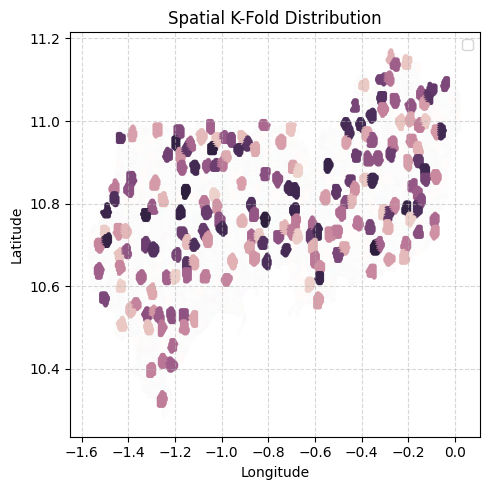

In [25]:
# Plot the folds
plt.figure(figsize=(5, 5))
sns.scatterplot(data=train_metadata_df, x='lon', y='lat', hue='fold_idx', palette='tab20', s=1, alpha=0.02, edgecolor=None)
sns.scatterplot(data=test_metadata_df, x='lon', y='lat', hue='fold_idx', color='r', s=10, alpha=1, edgecolor=None)

plt.title('Spatial K-Fold Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend([])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

# Train

In [26]:
def train_test_lgbm(X_train, y_train, X_test, y_test, groups, n_splits=2, n_trials=3):
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(direction="maximize") 
    study.optimize(optuna_objective_factory(X_train, y_train, groups, n_splits), n_trials=n_trials, show_progress_bar=True)
    
    # Build final model
    clf = lgb.LGBMClassifier(**study.best_params)
    clf.fit(X_train, y_train)
    
    yhat_train = clf.predict(X_train)
    yhat_test = clf.predict(X_test)

    # Validation-inferred correction
    yhat_vals = [np.array(e) for e in study.best_trial.user_attrs['yhat_vals']]
    y_vals = [np.array(e) for e in study.best_trial.user_attrs['y_vals']]
    ahat, (ci_lower, ci_upper) = compute_ahat(yhat_test, y_vals, yhat_vals)
    a = compute_a(y_test)
    print(f"Test region's estimated CAP: {ahat*100:.2f}% ({100 * ahat / a - 100:.2f}% off ETHZ's estimate)")
    print(f"95% Confidence Interval: [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
    
    print("\n--- OPTIMIZED MODEL EVALUATION ---")
    print("TRAIN")
    print(f"- F1: {f1_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_train, yhat_train, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_train, yhat_train, zero_division=0):.4f}")
    
    print("\nTEST")
    print(f"- F1: {f1_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Precision: {precision_score(y_test, yhat_test, zero_division=0):.4f}")
    print(f"- Recall: {recall_score(y_test, yhat_test, zero_division=0):.4f}")

    return clf, study.best_trial.user_attrs

In [35]:
def train_region(Xy, metadata_df, region, test_size=0.2, n_splits=2, n_trials=1):
    
    # Get train:test
    Xy_train, train_metadata_df, Xy_test, test_metadata_df = train_test_split(Xy, metadata_df, region.lower(), test_size)    
    X_train, y_train = Xy_train.drop(columns=['y']), Xy_train.y
    X_test, y_test = Xy_test.drop(columns=['y']), Xy_test.y

    # Train
    clf, user_attrs = train_test_lgbm(X_train, y_train, X_test, y_test, train_metadata_df.fold_idx, n_splits=n_splits, n_trials=n_trials);
    
    # Dump
    payload = {
        'X_train': X_train,
        'y_train': y_train,
        'metadata_df_train':  train_metadata_df,
        'X_test': X_test,
        'y_test': y_test,
        'metadata_df_test':  test_metadata_df,
        'clf': clf,
        "user_attrs": user_attrs,
    }
    
    joblib.dump(payload, f'trained-{region.lower()}-2021.joblib')

In [36]:
train_region(Xy, metadata_df, 'ashanti', 0.5, n_splits=20, n_trials=20)

Discarding out-of-region points: Kept 95807/915540 (10.46%)
500/1000 regions for testing (47878 points)


[I 2026-06-24 11:47:28,286] A new study created in memory with name: no-name-fd24821a-4240-478f-af8d-d1c6ce991775


Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-24 11:47:43,449] Trial 0 finished with value: 0.7637242324115066 and parameters: {'n_estimators': 61, 'learning_rate': 0.12768552295680455, 'max_depth': 4, 'num_leaves': 108, 'subsample': 0.7461439306974612, 'colsample_bytree': 0.8568998276124355, 'min_child_samples': 73}. Best is trial 0 with value: 0.7637242324115066.
[I 2026-06-24 11:48:33,075] Trial 1 finished with value: 0.7420479893892808 and parameters: {'n_estimators': 67, 'learning_rate': 0.023698086875943887, 'max_depth': 10, 'num_leaves': 90, 'subsample': 0.9711401892007633, 'colsample_bytree': 0.8360597915220105, 'min_child_samples': 38}. Best is trial 0 with value: 0.7637242324115066.
[I 2026-06-24 11:49:19,457] Trial 2 finished with value: 0.7730047525401508 and parameters: {'n_estimators': 88, 'learning_rate': 0.05898554570556348, 'max_depth': 10, 'num_leaves': 95, 'subsample': 0.7643286453293775, 'colsample_bytree': 0.6611730403518661, 'min_child_samples': 43}. Best is trial 2 with value: 0.7730047525401508.


In [37]:
train_region(Xy, metadata_df, 'western north', 0.5, n_splits=20, n_trials=20)

[I 2026-06-24 12:01:21,901] A new study created in memory with name: no-name-1f769585-33d7-4de1-b5e8-b863ec808799


Discarding out-of-region points: Kept 32268/915540 (3.52%)
500/1000 regions for testing (16042 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-24 12:01:31,975] Trial 0 finished with value: 0.8132767841755828 and parameters: {'n_estimators': 62, 'learning_rate': 0.012310300344447543, 'max_depth': 6, 'num_leaves': 145, 'subsample': 0.5900854615772523, 'colsample_bytree': 0.8146776986287754, 'min_child_samples': 82}. Best is trial 0 with value: 0.8132767841755828.
[I 2026-06-24 12:01:43,695] Trial 1 finished with value: 0.8310651728637135 and parameters: {'n_estimators': 55, 'learning_rate': 0.11202875059130779, 'max_depth': 8, 'num_leaves': 108, 'subsample': 0.7030598199645857, 'colsample_bytree': 0.5080046909349833, 'min_child_samples': 69}. Best is trial 1 with value: 0.8310651728637135.
[I 2026-06-24 12:01:57,856] Trial 2 finished with value: 0.8283915328582532 and parameters: {'n_estimators': 61, 'learning_rate': 0.03508031136708596, 'max_depth': 9, 'num_leaves': 50, 'subsample': 0.6169447094922701, 'colsample_bytree': 0.887866318436782, 'min_child_samples': 92}. Best is trial 1 with value: 0.8310651728637135.
[I

In [38]:
train_region(Xy, metadata_df, 'western', 0.5, n_splits=20, n_trials=20)

[I 2026-06-24 12:12:37,890] A new study created in memory with name: no-name-d9345118-488e-4099-8e8d-7c9df3664b62


Discarding out-of-region points: Kept 37872/915540 (4.14%)
500/1000 regions for testing (19010 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-24 12:12:44,162] Trial 0 finished with value: 0.7827006895279385 and parameters: {'n_estimators': 60, 'learning_rate': 0.187120405664922, 'max_depth': 2, 'num_leaves': 134, 'subsample': 0.7186796277082235, 'colsample_bytree': 0.8489888047610928, 'min_child_samples': 47}. Best is trial 0 with value: 0.7827006895279385.
[I 2026-06-24 12:12:56,434] Trial 1 finished with value: 0.7979329004329004 and parameters: {'n_estimators': 76, 'learning_rate': 0.09453092145311177, 'max_depth': 5, 'num_leaves': 126, 'subsample': 0.774628627227321, 'colsample_bytree': 0.6107671049349788, 'min_child_samples': 14}. Best is trial 1 with value: 0.7979329004329004.
[I 2026-06-24 12:13:03,010] Trial 2 finished with value: 0.746666758264406 and parameters: {'n_estimators': 53, 'learning_rate': 0.021037969927960736, 'max_depth': 3, 'num_leaves': 80, 'subsample': 0.5553272085713827, 'colsample_bytree': 0.6150568147182478, 'min_child_samples': 30}. Best is trial 1 with value: 0.7979329004329004.
[I 20

In [39]:
train_region(Xy, metadata_df, 'ahafo', 0.5, n_splits=20, n_trials=20)

[I 2026-06-24 12:22:02,522] A new study created in memory with name: no-name-109c6a89-b602-4371-ae87-e192d8615241


Discarding out-of-region points: Kept 20052/915540 (2.19%)
500/1000 regions for testing (10013 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-24 12:22:20,912] Trial 0 finished with value: 0.8034116751858237 and parameters: {'n_estimators': 65, 'learning_rate': 0.028264466464016126, 'max_depth': 10, 'num_leaves': 178, 'subsample': 0.634755270920055, 'colsample_bytree': 0.9600543066817351, 'min_child_samples': 88}. Best is trial 0 with value: 0.8034116751858237.
[I 2026-06-24 12:22:46,286] Trial 1 finished with value: 0.8108392528282031 and parameters: {'n_estimators': 83, 'learning_rate': 0.023030860215242366, 'max_depth': 8, 'num_leaves': 167, 'subsample': 0.5478579440955706, 'colsample_bytree': 0.6554695010825704, 'min_child_samples': 25}. Best is trial 1 with value: 0.8108392528282031.
[I 2026-06-24 12:22:55,382] Trial 2 finished with value: 0.8108246636360863 and parameters: {'n_estimators': 56, 'learning_rate': 0.07608056138525927, 'max_depth': 6, 'num_leaves': 143, 'subsample': 0.8113259185464157, 'colsample_bytree': 0.9417500258418183, 'min_child_samples': 65}. Best is trial 1 with value: 0.8108392528282031.

In [40]:
train_region(Xy, metadata_df, 'central', 0.5, n_splits=20, n_trials=20)

[I 2026-06-24 12:29:16,017] A new study created in memory with name: no-name-c217a9e2-a0a6-4f9b-befd-16e33b06b88b


Discarding out-of-region points: Kept 32385/915540 (3.54%)
500/1000 regions for testing (16105 points)
Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-24 12:29:25,718] Trial 0 finished with value: 0.7516727209276503 and parameters: {'n_estimators': 98, 'learning_rate': 0.06777556678587851, 'max_depth': 4, 'num_leaves': 26, 'subsample': 0.640326288198183, 'colsample_bytree': 0.6948764253010221, 'min_child_samples': 86}. Best is trial 0 with value: 0.7516727209276503.
[I 2026-06-24 12:30:02,335] Trial 1 finished with value: 0.7630466866503497 and parameters: {'n_estimators': 88, 'learning_rate': 0.04021158263459304, 'max_depth': 11, 'num_leaves': 149, 'subsample': 0.6337586280476496, 'colsample_bytree': 0.6934677523445063, 'min_child_samples': 68}. Best is trial 1 with value: 0.7630466866503497.
[I 2026-06-24 12:30:36,876] Trial 2 finished with value: 0.7435841231403003 and parameters: {'n_estimators': 89, 'learning_rate': 0.02348566484007178, 'max_depth': 8, 'num_leaves': 197, 'subsample': 0.8501850192228613, 'colsample_bytree': 0.6652540678719012, 'min_child_samples': 25}. Best is trial 1 with value: 0.7630466866503497.
[I

In [41]:
train_region(Xy, metadata_df, 'eastern', 0.5, n_splits=20, n_trials=20)

Discarding out-of-region points: Kept 68182/915540 (7.45%)
500/1000 regions for testing (34092 points)


[I 2026-06-24 12:37:08,169] A new study created in memory with name: no-name-36b1bf2b-39df-41e5-8ea6-4a2fb01cbd5c


Starting Optuna hyperparameter optimization...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-06-24 12:37:39,136] Trial 0 finished with value: 0.6470047086361286 and parameters: {'n_estimators': 74, 'learning_rate': 0.049338509526017725, 'max_depth': 8, 'num_leaves': 90, 'subsample': 0.6974463803486619, 'colsample_bytree': 0.7222197268094335, 'min_child_samples': 34}. Best is trial 0 with value: 0.6470047086361286.
[I 2026-06-24 12:38:33,861] Trial 1 finished with value: 0.5553432075171205 and parameters: {'n_estimators': 80, 'learning_rate': 0.01847219135973284, 'max_depth': 13, 'num_leaves': 193, 'subsample': 0.7803154571205333, 'colsample_bytree': 0.6099795546450784, 'min_child_samples': 84}. Best is trial 0 with value: 0.6470047086361286.
[I 2026-06-24 12:38:58,112] Trial 2 finished with value: 0.6549392791362812 and parameters: {'n_estimators': 54, 'learning_rate': 0.08633971344636521, 'max_depth': 8, 'num_leaves': 123, 'subsample': 0.9709347014714345, 'colsample_bytree': 0.6146955317539813, 'min_child_samples': 39}. Best is trial 2 with value: 0.6549392791362812.


# Use TCA
https://en.wikipedia.org/wiki/Tasseled_cap_transformation

# Use clustering min ?